<a href="https://colab.research.google.com/github/tonywahome/linear_regression_model/blob/main/Anxiety_Predicting_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Import Required Datasets

In [38]:
#import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



## Load Datasets

In [39]:
# Load the dataset
suicide_2019_df = pd.read_csv(r'C:\Users\LENOVO\Cloned repos\lrm_summative\linear_regression_model\summative\mental_health_data\suicide_rates_2019.csv')
mental_health_df = pd.read_csv(r'C:\Users\LENOVO\Cloned repos\lrm_summative\linear_regression_model\summative\mental_health_data\Mental health Depression disorder Data.csv')
anxiety_df = pd.read_csv(r'C:\Users\LENOVO\Cloned repos\lrm_summative\linear_regression_model\summative\mental_health_data\prevalence-of-anxiety-disorders-males-vs-females.csv')
bipolar_df = pd.read_csv(r'C:\Users\LENOVO\Cloned repos\lrm_summative\linear_regression_model\summative\mental_health_data\prevalence-of-anxiety-disorders-males-vs-females.csv')
eating_disorder_df = pd.read_csv(r'C:\Users\LENOVO\Cloned repos\lrm_summative\linear_regression_model\summative\mental_health_data\prevalence-of-eating-disorders-in-males-vs-females.csv')
schizophrenia_df = pd.read_csv(r'C:\Users\LENOVO\Cloned repos\lrm_summative\linear_regression_model\summative\mental_health_data\prevalence-of-schizophrenia-in-males-vs-females.csv')
road_deaths_df = pd.read_csv(r'C:\Users\LENOVO\Cloned repos\lrm_summative\linear_regression_model\summative\mental_health_data\road_death_2019.csv')
suicide_rate_df = pd.read_csv(r'C:\Users\LENOVO\Cloned repos\lrm_summative\linear_regression_model\summative\mental_health_data\suicide-rate-by-country-2023.csv')
worldHappiness_df = pd.read_csv(r'C:\Users\LENOVO\Cloned repos\lrm_summative\linear_regression_model\summative\mental_health_data\World Happiness Report 2005-2021.csv')
depression_df = pd.read_csv(r'C:\Users\LENOVO\Cloned repos\lrm_summative\linear_regression_model\summative\mental_health_data\prevalence-of-depression-males-vs-females.csv')



display(mental_health_df)
display(suicide_2019_df)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_33704\3527259133.py:3: DtypeWarning: Columns (5,6) have mixed types. Specify dtype option on import or set low_memory=False.
  mental_health_df = pd.read_csv(r'C:\Users\LENOVO\Cloned repos\lrm_summative\linear_regression_model\summative\mental_health_data\Mental health Depression disorder Data.csv')


,index,Entity,Code,Year,Schizophrenia (%),Bipolar disorder (%),Eating disorders (%),Anxiety disorders (%),Drug use disorders (%),Depression (%),Alcohol use disorders (%)
0,0,Afghanistan,AFG,1990,0.16056,0.697779,0.101855,4.828830,1.677082,4.071831,0.672404
1,1,Afghanistan,AFG,1991,0.160312,0.697961,0.099313,4.829740,1.684746,4.079531,0.671768
2,2,Afghanistan,AFG,1992,0.160135,0.698107,0.096692,4.831108,1.694334,4.088358,0.670644
3,3,Afghanistan,AFG,1993,0.160037,0.698257,0.094336,4.830864,1.705320,4.096190,0.669738
4,4,Afghanistan,AFG,1994,0.160022,0.698469,0.092439,4.829423,1.716069,4.099582,0.669260
...,...,...,...,...,...,...,...,...,...,...,...
108548,108548,Zimbabwe,ZWE,2013,303564.60359,NaN,NaN,NaN,NaN,NaN,NaN
108549,108549,Zimbabwe,ZWE,2014,311665.769283,NaN,NaN,NaN,NaN,NaN,NaN
108550,108550,Zimbabwe,ZWE,2015,320638.507158,NaN,NaN,NaN,NaN,NaN,NaN
108551,108551,Zimbabwe,ZWE,2016,330437.353798,NaN,NaN,NaN,NaN,NaN,NaN


,Indicator,continent,code,country,year,sex,Suicide Rate
0,Age-standardized suicide rates (per 100 000 po...,Americas,ATG,Antigua and Barbuda,2019,Male,0.00
1,Age-standardized suicide rates (per 100 000 po...,Americas,BRB,Barbados,2019,Female,0.16
2,Age-standardized suicide rates (per 100 000 po...,Americas,BRB,Barbados,2019,Both sexes,0.31
3,Age-standardized suicide rates (per 100 000 po...,Americas,ATG,Antigua and Barbuda,2019,Both sexes,0.32
4,Age-standardized suicide rates (per 100 000 po...,Americas,BRB,Barbados,2019,Male,0.49
...,...,...,...,...,...,...,...
10975,Age-standardized suicide rates (per 100 000 po...,Africa,GIN,Guinea,2000,Both sexes,9.73
10976,Age-standardized suicide rates (per 100 000 po...,Africa,GHA,Ghana,2000,Both sexes,9.75
10977,Age-standardized suicide rates (per 100 000 po...,Europe,MLT,Malta,2000,Male,9.75
10978,Age-standardized suicide rates (per 100 000 po...,Africa,SYC,Seychelles,2000,Both sexes,9.76


## Clean and Filter each DataFrame for the Year 2019

In [40]:
# Clean the Suicide Rates DataFrame

if not suicide_2019_df.empty:
    # Filter for years between 2000 and 2019 and 'Both sexes'
    suicide_2000_2019_df = suicide_2019_df[(suicide_2019_df['year'] >= 2000) & (suicide_2019_df['year'] <= 2019) & (suicide_2019_df['sex'] == 'Both sexes')].copy()
    # Select and rename relevant columns
    suicide_2000_2019_df = suicide_2000_2019_df[['country', 'year', 'Suicide Rate']].copy()
    suicide_2000_2019_df.rename(columns={'country': 'Country'}, inplace=True)

display(suicide_2000_2019_df)

,Country,year,Suicide Rate
2,Barbados,2019,0.31
3,Antigua and Barbuda,2019,0.32
7,Grenada,2019,0.64
19,Saint Vincent and the Grenadines,2019,1.01
48,Jordan,2019,1.98
...,...,...,...
10961,Argentina,2000,9.20
10969,Niger,2000,9.51
10975,Guinea,2000,9.73
10976,Ghana,2000,9.75


In [41]:
# Clean the World Happiness Report DataFrame
if not worldHappiness_df.empty:
    # Filter for the years between 2000 and 2019
    happiness_2000_2019_df = worldHappiness_df[(worldHappiness_df['Year'] >= 2000) & (worldHappiness_df['Year'] <= 2019)].copy()
    # Select and rename relevant columns
    happiness_2000_2019_df = happiness_2000_2019_df[[
        'Country name', 'Year', 'Log GDP per capita', 'Social support',
        'Healthy life expectancy at birth', 'Freedom to make life choices',
        'Generosity', 'Perceptions of corruption', 'Negative affect'
    ]]
    happiness_2000_2019_df.rename(columns={'Country name': 'Country'}, inplace=True)

display(happiness_2000_2019_df)

,Country,Year,Log GDP per capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption,Negative affect
0,Afghanistan,2008,7.302574,0.450662,50.500000,0.718114,0.173169,0.881686,0.258195
1,Afghanistan,2009,7.472446,0.552308,50.799999,0.678896,0.195469,0.850035,0.237092
2,Afghanistan,2010,7.579183,0.539075,51.099998,0.600127,0.125859,0.706766,0.275324
3,Afghanistan,2011,7.552006,0.521104,51.400002,0.495901,0.167723,0.731109,0.267175
4,Afghanistan,2012,7.637953,0.520637,51.700001,0.530935,0.241247,0.775620,0.267919
...,...,...,...,...,...,...,...,...,...
2082,Zimbabwe,2015,8.218146,0.735800,51.200001,0.667193,-0.139437,0.810457,0.178861
2083,Zimbabwe,2016,8.210183,0.768425,51.674999,0.732971,-0.110893,0.723612,0.208555
2084,Zimbabwe,2017,8.241609,0.754147,52.150002,0.752826,-0.113937,0.751208,0.224051
2085,Zimbabwe,2018,8.274620,0.775388,52.625000,0.762675,-0.084747,0.844209,0.211726


## Merge the DataFrames into a single Master Dataset

- Converting to Numeric Datatype


In [42]:
if not mental_health_df.empty:
    # Convert 'Year' to numeric, coercing errors to NaN
    mental_health_df['Year'] = pd.to_numeric(mental_health_df['Year'], errors='coerce')
    # Drop rows where 'Year' could not be converted
    mental_health_df.dropna(subset=['Year'], inplace=True)
    # Convert 'Year' to integer after dropping NaNs
    mental_health_df['Year'] = mental_health_df['Year'].astype(int)

    # Filter for years between 2000 and 2019
    mental_health_2000_2019_df = mental_health_df[(mental_health_df['Year'] >= 2000) & (mental_health_df['Year'] <= 2019)].copy()
    # Select and rename relevant columns
    mental_health_2000_2019_df = mental_health_2000_2019_df[[
        'Entity', 'Year', 'Schizophrenia (%)', 'Bipolar disorder (%)', 'Eating disorders (%)',
        'Anxiety disorders (%)', 'Drug use disorders (%)', 'Depression (%)', 'Alcohol use disorders (%)'
    ]]
    mental_health_2000_2019_df.rename(columns={'Entity': 'Country'}, inplace=True)

display(mental_health_2000_2019_df)

,Country,Year,Schizophrenia (%),Bipolar disorder (%),Eating disorders (%),Anxiety disorders (%),Drug use disorders (%),Depression (%),Alcohol use disorders (%)
10,Afghanistan,2000,0.161621,0.700015,0.086021,4.827047,1.788395,4.118610,0.662479
11,Afghanistan,2001,0.161957,0.700499,0.086517,4.831409,1.839123,4.121381,0.661158
12,Afghanistan,2002,0.162414,0.701141,0.087023,4.838318,1.934326,4.124928,0.659213
13,Afghanistan,2003,0.162916,0.70186,0.087189,4.845538,2.051106,4.125230,0.657354
14,Afghanistan,2004,0.163377,0.702556,0.088158,4.851512,2.163044,4.126384,0.656132
...,...,...,...,...,...,...,...,...,...
108548,Zimbabwe,2013,303564.60359,NaN,NaN,NaN,NaN,NaN,NaN
108549,Zimbabwe,2014,311665.769283,NaN,NaN,NaN,NaN,NaN,NaN
108550,Zimbabwe,2015,320638.507158,NaN,NaN,NaN,NaN,NaN,NaN
108551,Zimbabwe,2016,330437.353798,NaN,NaN,NaN,NaN,NaN,NaN


In [43]:
# Merge suicide and happiness dataframes
master_df = pd.merge(suicide_2000_2019_df, happiness_2000_2019_df, how='inner', left_on=['Country', 'year'], right_on=['Country', 'Year'])

# Drop the redundant 'Year' column from the merged dataframe
master_df.drop(columns=['Year'], inplace=True)

# Merge the master dataframe with the mental health dataframe
master_df = pd.merge(master_df, mental_health_2000_2019_df, how='inner', left_on=['Country', 'year'], right_on=['Country', 'Year'])

# Drop the redundant 'Year' column from the merged dataframe
master_df.drop(columns=['Year'], inplace=True)

display(master_df)

,Country,year,Suicide Rate,Log GDP per capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption,Negative affect,Schizophrenia (%),Bipolar disorder (%),Eating disorders (%),Anxiety disorders (%),Drug use disorders (%),Depression (%),Alcohol use disorders (%)
0,Jordan,2019,1.98,9.217453,0.792560,67.599998,0.725756,-0.167033,NaN,NaN,NaN,NaN,10102000.000000,NaN,NaN,NaN,NaN
1,Jordan,2019,1.98,9.217453,0.792560,67.599998,0.725756,-0.167033,NaN,NaN,NaN,NaN,10102000.0,NaN,NaN,NaN,NaN
2,Niger,2019,10.15,7.110186,0.676959,55.500000,0.831362,0.026541,0.728855,0.304438,NaN,NaN,23311000.000000,NaN,NaN,NaN,NaN
3,Niger,2019,10.15,7.110186,0.676959,55.500000,0.831362,0.026541,0.728855,0.304438,NaN,NaN,23311000.0,NaN,NaN,NaN,NaN
4,New Zealand,2019,10.30,10.666113,0.938821,70.199997,0.912042,0.154317,0.233831,0.191176,NaN,NaN,4783000,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5807,Netherlands,2005,8.26,10.809070,0.947358,70.699997,0.901008,NaN,0.571342,0.232795,692533.323794,NaN,NaN,NaN,NaN,NaN,NaN
5808,Germany,2005,9.81,10.690792,0.963490,69.900002,0.846624,NaN,0.781007,0.197262,0.252344,0.775454,0.499505,6.525485,0.868482,3.931693,1.968473
5809,Germany,2005,9.81,10.690792,0.963490,69.900002,0.846624,NaN,0.781007,0.197262,2.904383,4.903306,81603000.000000,NaN,NaN,NaN,NaN
5810,Germany,2005,9.81,10.690792,0.963490,69.900002,0.846624,NaN,0.781007,0.197262,10.618936,3550.975394,81603000.0,NaN,NaN,NaN,NaN


In [44]:
# Check for missing values
missing_values = master_df.isnull().sum()

# Print columns with missing values and their counts
print("Columns with missing values:")
print(missing_values[missing_values > 0])

Columns with missing values:
Log GDP per capita                20
Social support                    44
Freedom to make life choices      96
Generosity                       190
Perceptions of corruption        360
Negative affect                   46
Schizophrenia (%)                488
Bipolar disorder (%)            1819
Eating disorders (%)            1331
Anxiety disorders (%)           4481
Drug use disorders (%)          4481
Depression (%)                  4481
Alcohol use disorders (%)       4481
dtype: int64


## Remove Nulls

In [45]:
# Drop rows with any missing values
master_df.dropna(inplace=True)

# Verify that there are no remaining missing values
missing_values_after_drop = master_df.isnull().sum()

# Print columns with missing values and their counts after dropping
print("\nColumns with missing values after dropping rows:")
print(missing_values_after_drop[missing_values_after_drop > 0])

display(master_df)


Columns with missing values after dropping rows:
Series([], dtype: int64)


,Country,year,Suicide Rate,Log GDP per capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption,Negative affect,Schizophrenia (%),Bipolar disorder (%),Eating disorders (%),Anxiety disorders (%),Drug use disorders (%),Depression (%),Alcohol use disorders (%)
488,Serbia,2017,0.33,9.717821,0.883770,66.650002,0.684846,-0.079366,0.851458,0.326407,0.200264,0.699141,0.187147,3.404672,0.441905,2.570068,2.018133
496,Niger,2017,10.15,7.058953,0.582110,54.799999,0.683558,-0.029409,0.777660,0.426522,0.163845,0.631572,0.096116,2.891358,0.462455,3.463055,0.911306
500,Uganda,2017,10.34,7.637549,0.739956,57.250000,0.772344,0.060091,0.815770,0.400026,0.160208,0.61042,0.119309,3.526626,0.542832,4.918028,1.295986
504,Switzerland,2017,10.37,11.143362,0.949661,72.099998,0.924997,0.174821,0.316183,0.195871,0.262487,0.953996,0.573969,5.359393,1.006218,3.708060,1.379690
508,Norway,2017,10.38,11.067431,0.950128,71.300003,0.953017,0.232320,0.249711,0.202914,0.211484,0.856901,0.570363,7.585503,0.832286,3.771910,1.419003
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5700,Mali,2006,8.65,7.592722,0.761116,49.939999,0.555076,-0.071363,0.761046,0.208563,0.165814,0.625945,0.109366,2.880529,0.422806,2.932080,0.884428
5704,Nigeria,2006,9.16,8.326130,0.735179,50.220001,0.649140,0.084604,0.870749,0.178237,0.175916,0.638032,0.133472,2.848603,0.445117,4.075633,0.908810
5708,Uzbekistan,2006,9.59,8.255723,0.903067,61.340000,0.784301,-0.120173,0.608808,0.195058,0.183271,0.665004,0.128283,2.543994,0.451233,2.914497,2.207984
5712,Chile,2006,9.72,9.883473,0.835544,67.779999,0.744292,0.164268,0.633630,0.347657,0.199124,0.786617,0.366387,6.264955,1.107557,4.183396,2.585168


In [74]:
# convert schizophrenia, bipolar disorder, eating disorders, anxiety disorders, drug use disorders, depression, and alcohol use disorders to numeric
columns_to_convert = [
    'Schizophrenia (%)', 'Bipolar disorder (%)', 'Eating disorders (%)',
    'Anxiety disorders (%)', 'Drug use disorders (%)']
for column in columns_to_convert:
    master_df[column] = pd.to_numeric(master_df[column], errors='coerce')
master_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1204 entries, 488 to 5732
Data columns (total 21 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Country                               1204 non-null   object 
 1   year                                  1204 non-null   int64  
 2   Suicide Rate                          1204 non-null   float64
 3   Log GDP per capita                    1204 non-null   float64
 4   Social support                        1204 non-null   float64
 5   Healthy life expectancy at birth      1204 non-null   float64
 6   Freedom to make life choices          1204 non-null   float64
 7   Generosity                            1204 non-null   float64
 8   Perceptions of corruption             1204 non-null   float64
 9   Negative affect                       1204 non-null   float64
 10  Schizophrenia (%)                     1204 non-null   float64
 11  Bipolar disorder (%)

## Summary:

### Data Analysis Key Findings

* The merging process successfully combined data from suicide rates, happiness scores, and mental health disorder prevalence.
* Initially, there were inconsistencies in the year column name across the dataframes (`year` vs. `Year`), which were resolved by using `left_on` and `right_on` during merging.
* After merging, the master dataframe contained significant missing values, particularly in the mental health disorder columns.
* Dropping rows with any missing values resulted in a final master dataframe with 1204 entries and 17 columns, free of null values.

### Insights or Next Steps

* The significant number of dropped rows due to missing values suggests that imputation or alternative strategies for handling missing data could be explored in the future to retain more information.
* The resulting master dataframe is now ready for exploratory data analysis to investigate potential relationships between suicide rates, happiness, and various mental health disorders.

Explolatory Data Analysis

Data Viz

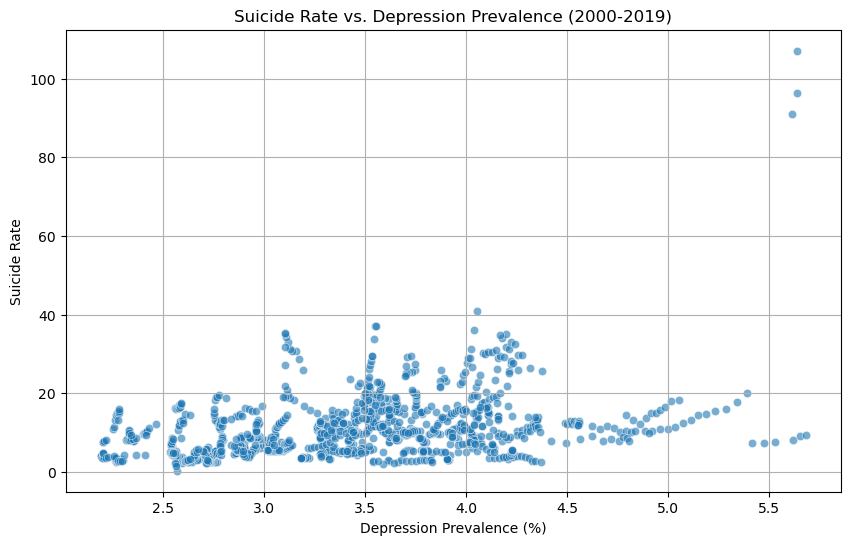

In [75]:
# prompt: plot a scatter plot showing the relationship between suicide rates and depression

plt.figure(figsize=(10, 6))
sns.scatterplot(data=master_df, x='Depression (%)', y='Suicide Rate', alpha=0.6)
plt.title('Suicide Rate vs. Depression Prevalence (2000-2019)')
plt.xlabel('Depression Prevalence (%)')
plt.ylabel('Suicide Rate')
plt.grid(True)
plt.show()

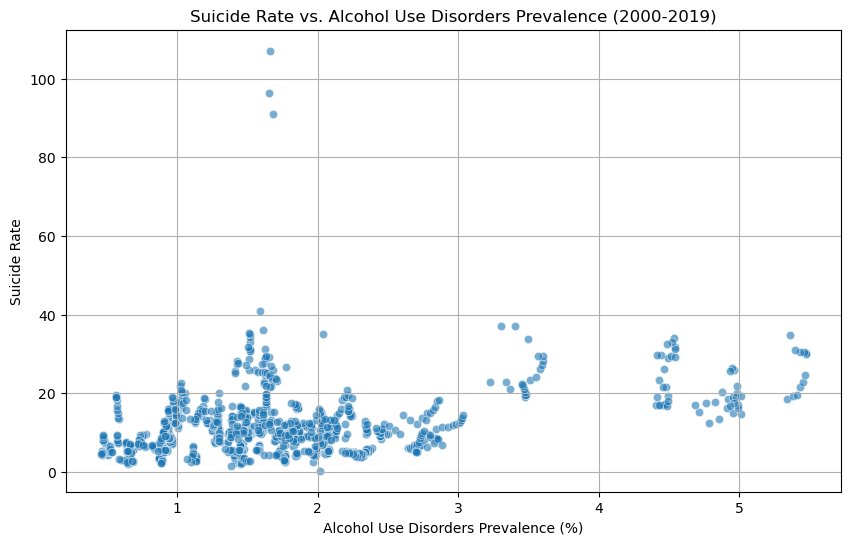

In [76]:
# prompt: line graph showing the relationship between suicide and alcohol substance

plt.figure(figsize=(10, 6))
sns.scatterplot(data=master_df, x='Alcohol use disorders (%)', y='Suicide Rate', alpha=0.6)
plt.title('Suicide Rate vs. Alcohol Use Disorders Prevalence (2000-2019)')
plt.xlabel('Alcohol Use Disorders Prevalence (%)')
plt.ylabel('Suicide Rate')
plt.grid(True)
plt.show()

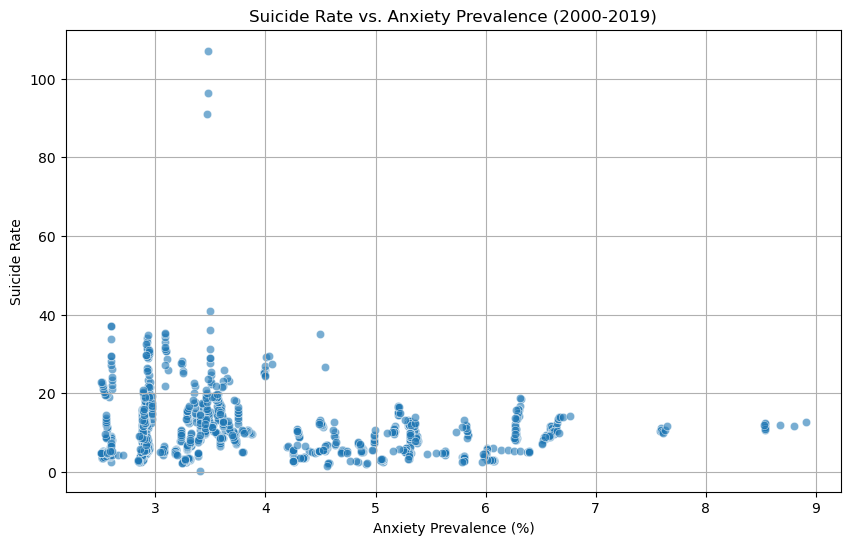

In [77]:
# prompt: plot scatter plot to show relationship between anxiety and suicide

plt.figure(figsize=(10, 6))
sns.scatterplot(data=master_df, x='Anxiety disorders (%)', y='Suicide Rate', alpha=0.6)
plt.title('Suicide Rate vs. Anxiety Prevalence (2000-2019)')
plt.xlabel('Anxiety Prevalence (%)')
plt.ylabel('Suicide Rate')
plt.grid(True)
plt.show()

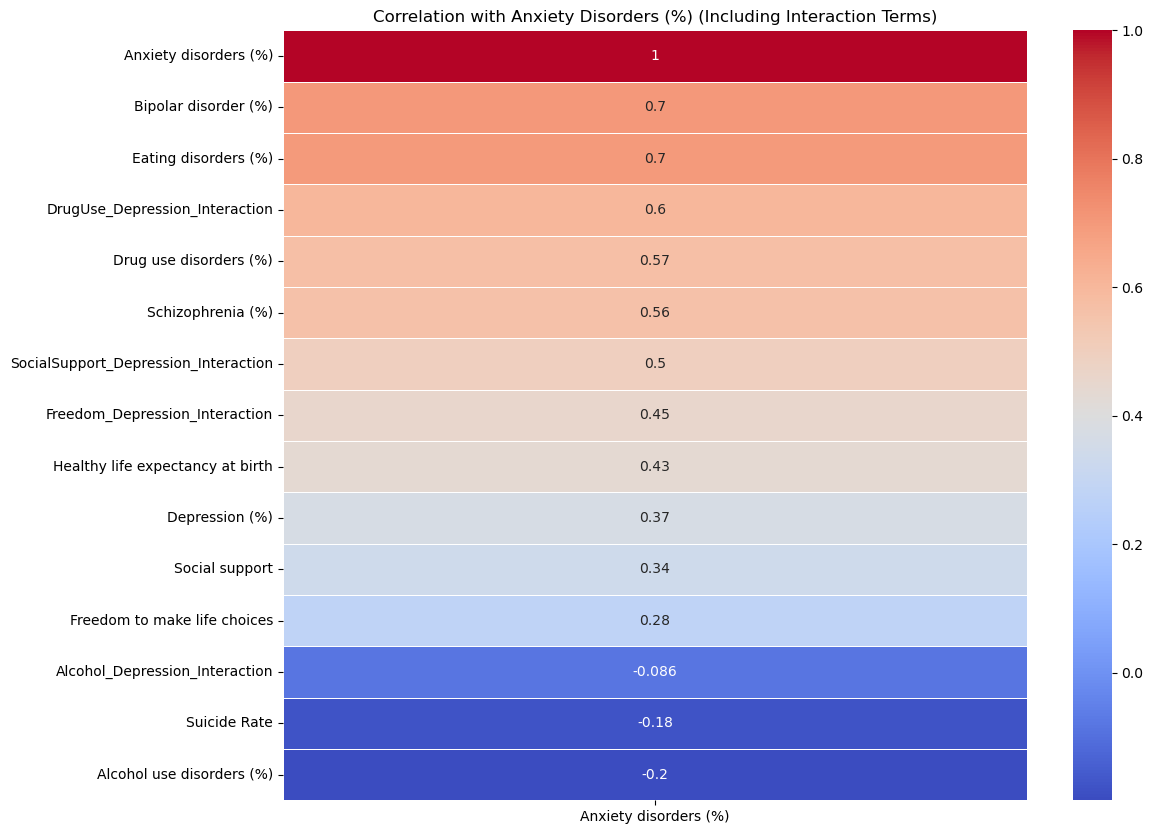

In [78]:
# Create interaction terms
master_df['Freedom_Depression_Interaction'] = master_df['Freedom to make life choices'] * master_df['Depression (%)']
master_df['Alcohol_Depression_Interaction'] = master_df['Alcohol use disorders (%)'] * master_df['Depression (%)']
master_df['DrugUse_Depression_Interaction'] = master_df['Drug use disorders (%)'] * master_df['Depression (%)']
master_df['SocialSupport_Depression_Interaction'] = master_df['Social support'] * master_df['Depression (%)']

# Select only numeric columns for correlation calculation, including the new interaction terms
numeric_master_df = master_df.select_dtypes(include=np.number)

# Drop columns that are not relevant for the heatmap visualization of relationships with Anxiety
columns_to_drop_from_heatmap = ['year', 'Perceptions of corruption', 'Generosity', 'Log GDP per capita', 'Negative affect']
numeric_master_df_filtered = numeric_master_df.drop(columns=columns_to_drop_from_heatmap, errors='ignore')

# Calculate the correlation matrix
corr_matrix = numeric_master_df_filtered.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix[['Anxiety disorders (%)']].sort_values(by='Anxiety disorders (%)', ascending=False), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation with Anxiety Disorders (%) (Including Interaction Terms)')
plt.show()

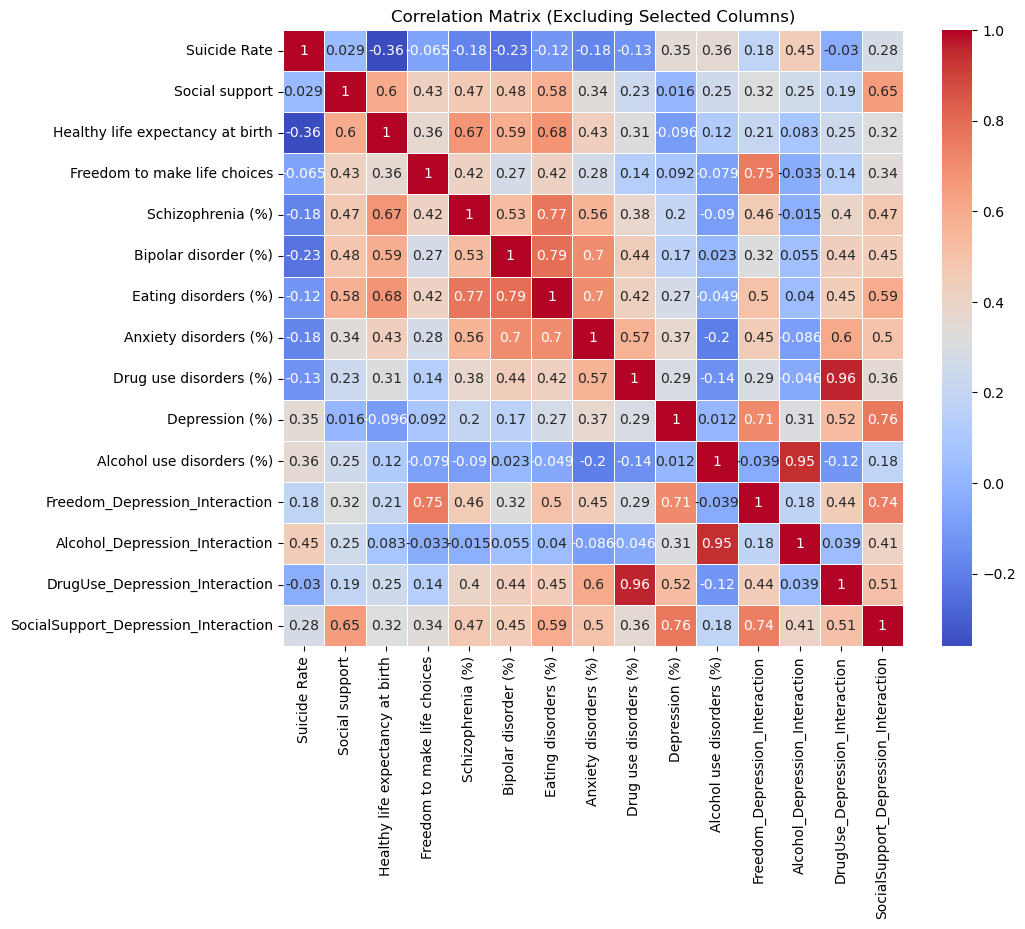

In [79]:
# Select only numeric columns for correlation calculation
numeric_master_df = master_df.select_dtypes(include=np.number)

# Drop specified columns for heatmap visualization
columns_to_drop_from_heatmap = ['year', 'Perceptions of corruption', 'Generosity', 'Log GDP per capita', 'Negative affect']
numeric_master_df_filtered = numeric_master_df.drop(columns=columns_to_drop_from_heatmap, errors='ignore')


# Calculate the correlation matrix
corr_matrix = numeric_master_df_filtered.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix (Excluding Selected Columns)')
plt.show()



**MODEL TRAINING**

80/20 Train/Test split

In [80]:
# Define features (X) and target (y)
# Drop non-numeric and target columns
X = master_df.drop(['Country', 'Anxiety disorders (%)'], axis=1)
y = master_df['Anxiety disorders (%)']




# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set shape:", X_train.shape, y_train.shape)
print("Testing set shape:", X_test.shape, y_test.shape)

Training set shape: (963, 19) (963,)
Testing set shape: (241, 19) (241,)


In [81]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Model coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Model coefficients: [-7.05341725e-05 -6.30038717e-03  7.28293887e-02  1.88015262e+00
  1.18178396e-05 -1.37079504e+00  9.82487974e-01  2.77511846e-02
  1.10521499e-01  7.72788965e-01  3.62321378e+00  1.03409469e+00
  7.84813874e-01  7.91786020e-01  6.24220529e-02  3.30161892e-01
 -6.17475785e-02 -6.31316656e-02 -5.68386702e-01]
Intercept: -2.3731040582724208


In [54]:
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R-squared:", r2)



Mean Squared Error: 0.5385551377358713
R-squared: 0.6651829629081529


In [55]:
#check coefficients
print("n\Feature Impact on Anxiety")
coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
coefficients = coefficients.sort_values(by='Coefficient', ascending=False)
print(coefficients)

n\Feature Impact on Anxiety
                                 Feature  Coefficient
10                  Bipolar disorder (%)     3.623214
3                         Social support     1.880153
11                  Eating disorders (%)     1.034095
6                             Generosity     0.982488
13                        Depression (%)     0.791786
12                Drug use disorders (%)     0.784814
9                      Schizophrenia (%)     0.772789
15        Freedom_Depression_Interaction     0.330162
8                        Negative affect     0.110521
2                     Log GDP per capita     0.072829
14             Alcohol use disorders (%)     0.062422
7              Perceptions of corruption     0.027751
4       Healthy life expectancy at birth     0.000012
0                                   year    -0.000071
1                           Suicide Rate    -0.006300
16        Alcohol_Depression_Interaction    -0.061748
17        DrugUse_Depression_Interaction    -0.063132


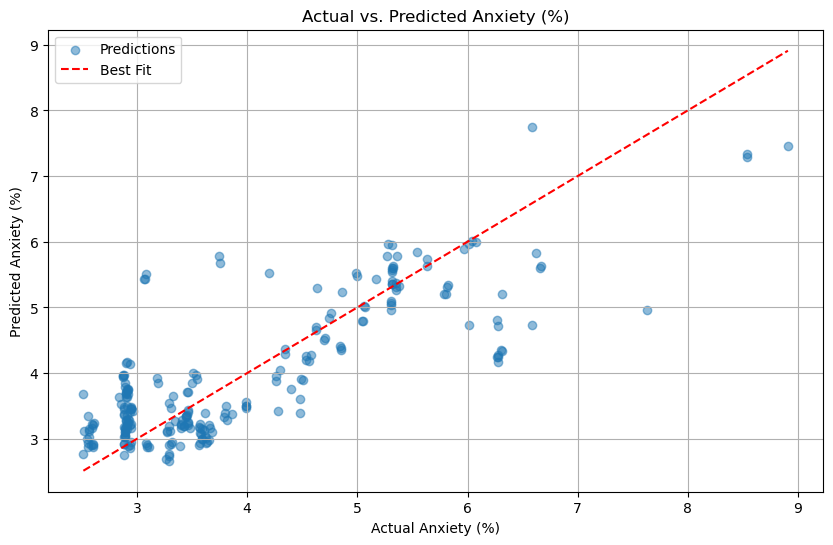

In [56]:
#plot linear regression line of actual anxiety vs predicted anxiety
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5, label='Predictions')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label = "Best Fit")
plt.xlabel('Actual Anxiety (%)')
plt.ylabel('Predicted Anxiety (%)')
plt.title('Actual vs. Predicted Anxiety (%)')
plt.grid(True)
plt.legend()
plt.show()

# Random Forest Model

In [57]:
from sklearn.ensemble import RandomForestRegressor


In [58]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

Predictions

In [59]:
y_pred_rf = rf_model.predict(X_test)

In [60]:
#evaluate
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

In [61]:
print("Random Forest - Mean Squared Error:", mse_rf)
print("Random Forest - R-squared:", r2_rf)

Random Forest - Mean Squared Error: 0.012569794041817338
Random Forest - R-squared: 0.9921854218759675


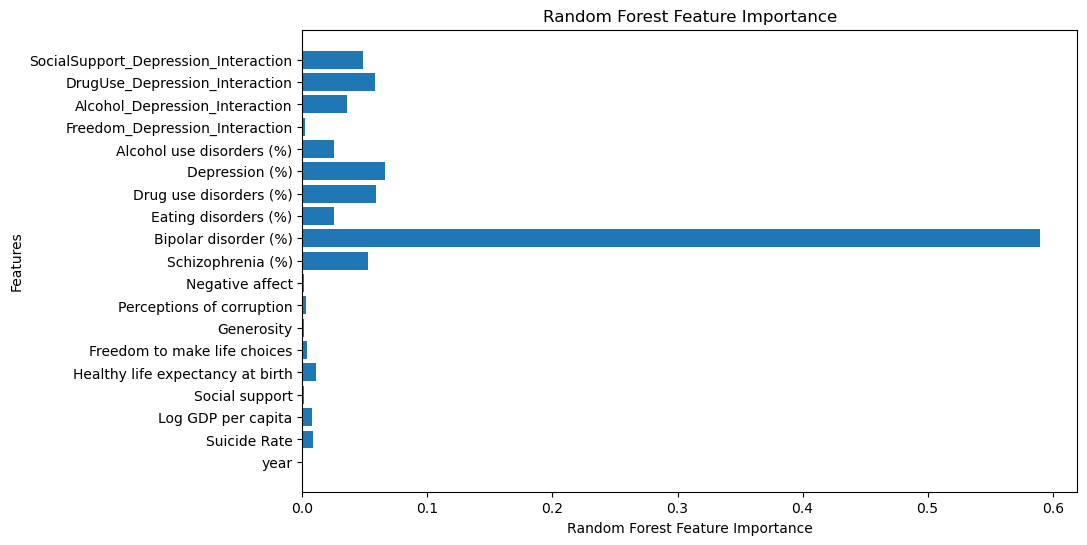

In [62]:
# get feature importances
importances = rf_model.feature_importances_
features = X.columns

plt.figure(figsize=(10, 6))
plt.barh(features, importances)
plt.xlabel('Random Forest Feature Importance')
plt.ylabel('Features')
plt.title('Random Forest Feature Importance')
plt.show()

In [63]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
}

grid_search = GridSearchCV(RandomForestRegressor(random_state=42),
                           param_grid, cv=5, scoring='r2'
                        )

grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

print("Best Parameters:", best_params)

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


## Decision Tree Model

In [64]:
from sklearn.tree import DecisionTreeRegressor


In [65]:
dt_model = DecisionTreeRegressor(random_state=42, max_depth=5)
dt_model.fit(X_train, y_train)


DecisionTreeRegressor(max_depth=5, random_state=42)

In [66]:
y_pred_dt = dt_model.predict(X_test)

In [67]:
#evaluate
mse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree - Mean Squared Error:", mse_dt)
print("Decision Tree - R-squared:", r2_dt)

Decision Tree - Mean Squared Error: 0.3359693335839866
Decision Tree - R-squared: 0.9298259323266846


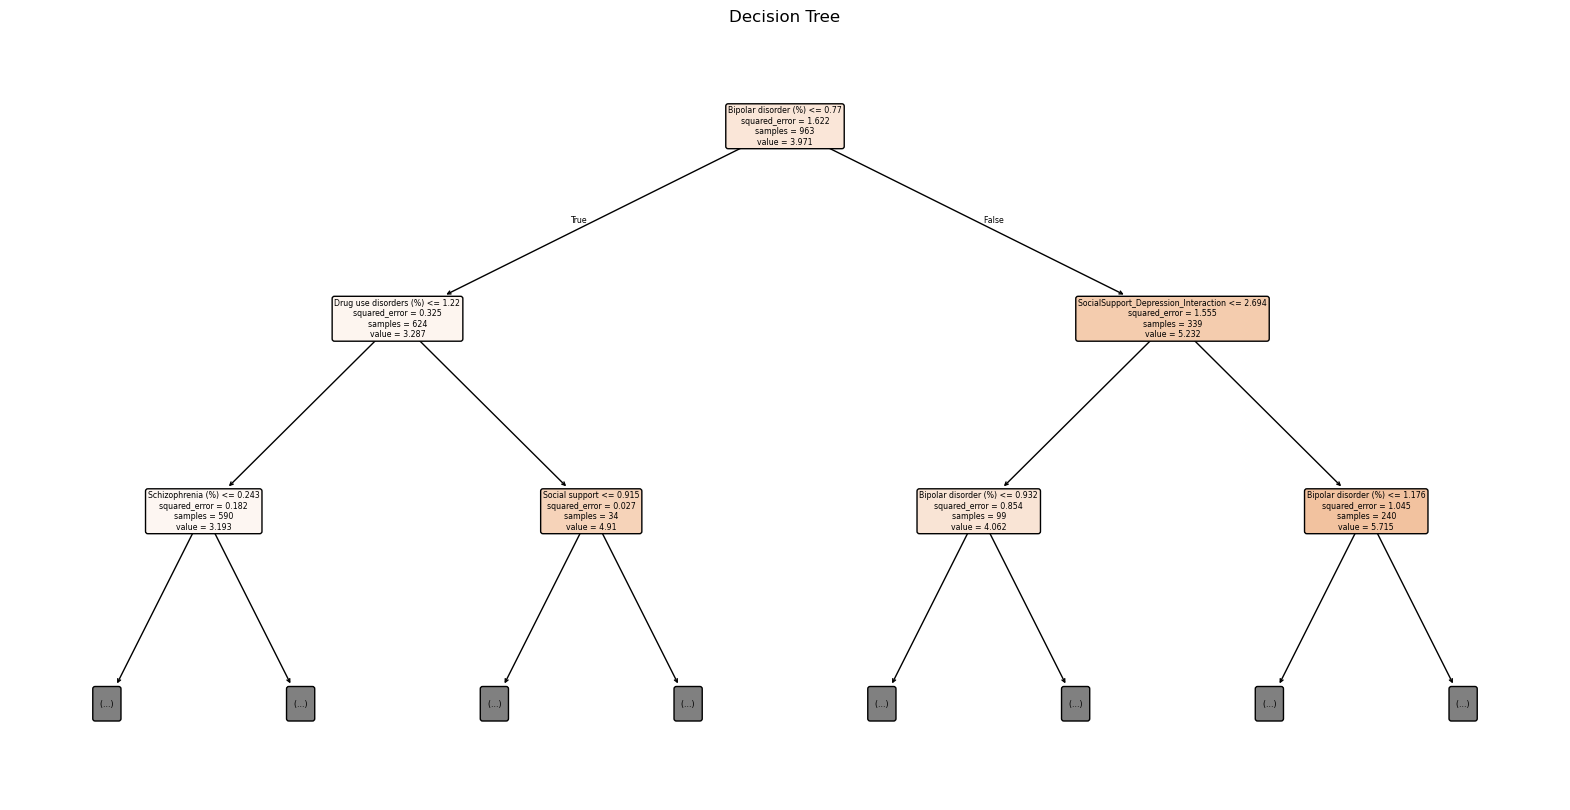

In [68]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(dt_model, filled=True, feature_names=X.columns, rounded=True, max_depth=2)
plt.title('Decision Tree')
plt.show()

## Model Comparison


In [69]:
#compare models
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Decision Tree'],
    'Mean Squared Error': [mse, mse_rf, mse_dt],
    'R-squared': [r2, r2_rf, r2_dt]
}).sort_values(by='R-squared', ascending=False)

print(results)

               Model  Mean Squared Error  R-squared
1      Random Forest            0.012570   0.992185
2      Decision Tree            0.335969   0.929826
0  Linear Regression            0.538555   0.665183


Since the Random Forest Model has the lowest Mean Squared Error and the Highest R Squared Value, it is the most appropriate model

In [70]:
import joblib

In [71]:
joblib.dump(rf_model, 'anxiety_model.pkl')

['anxiety_model.pkl']

In [72]:
import joblib

# Load the saved model
loaded_model = joblib.load('anxiety_model.pkl')

print("Model loaded successfully!")

Model loaded successfully!
